<a href="https://colab.research.google.com/github/SonalGire/LangGraph/blob/main/UPSC_Essay_evaluation_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3> <b>🧠 AI-Powered UPSC Essay Evaluator : </b></h3>

An intelligent UPSC essay evaluation system built using **LangGraph**, **LangChain**, and **Azure OpenAI**.

---


✨ This project evaluates essays based on:

* 📝 Language Quality
* 🔍 Depth of Analysis
* 💡 Clarity of Thought


Multiple AI evaluation nodes work in parallel and generate detailed feedback with scores for each section, followed by an overall summary 📊

### ⚙️ Tech Stack

* LangGraph
* LangChain
* Azure OpenAI
* Pydantic

🚀 A simple demonstration of Agentic AI workflows for educational and essay evaluation systems.


In [ ]:
!pip install langchain-openai

In [91]:
import warnings
# Suppress all UserWarnings. This is a very broad filter.
warnings.filterwarnings("ignore", category=UserWarning)

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [106]:
AZURE_OPENAI_API_KEY="57Q7DIM51v6RLy345rty"
AZURE_OPENAI_ENDPOINT="https:/"

LLM_MODEL="gpt"
API_VERSION="2022"


In [93]:
from langchain_openai import AzureChatOpenAI

# LLM Instances
llm = AzureChatOpenAI(
    azure_deployment=LLM_MODEL,
    api_version=API_VERSION,
    temperature=0.7,
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    streaming=False
)


In [94]:
class EvaluationSchema(BaseModel):
  feedback : str = Field(description='Detailed feedback for the essay')
  score: int = Field(description="Score out of 10", ge=0, le=10)

In [95]:
structured_model = llm.with_structured_output(EvaluationSchema)

In [96]:
essay = """# Rise of AI in India

Artificial Intelligence (AI) is one of the fastest-growing technologies in the world today. It is changing the way people work, study, communicate, and live. India is also becoming an important part of this AI revolution. From schools and hospitals to banks and mobile applications, AI is being used in many areas. The rise of AI in India is helping the country grow in technology and innovation.
AI means machines or computers that can perform tasks that usually require human intelligence. These tasks include understanding language, solving problems, recognizing images, and making decisions. Nowadays, many people use AI without even realizing it. Voice assistants like Siri and Google Assistant, online shopping recommendations, and chatbots are all examples of AI.
India has seen rapid growth in AI because of increasing internet usage and digital technology. More people now have smartphones and access to online services. This has created a large amount of digital data, which is important for AI systems. Indian companies and startups are using this data to create smarter applications and services.
The Indian government is also supporting AI development. Programs like Digital India and IndiaAI are encouraging the use of modern technology in different sectors. The government wants AI to improve healthcare, education, agriculture, and transportation. Many colleges and universities have also started offering courses related to AI, machine learning, and data science.
AI is helping many industries in India. In healthcare, AI helps doctors detect diseases and manage patient records. In agriculture, farmers use AI tools for weather prediction and crop monitoring. Banks use AI for customer service and fraud detection. Educational apps use AI to provide personalized learning experiences to students.
The IT industry in India is also benefiting from AI. Many software companies are creating AI-based products and services for clients around the world. This is creating new job opportunities for programmers, data scientists, and AI engineers. Young students are also becoming interested in learning AI-related skills because these skills are in high demand.
However, the rise of AI also brings some challenges. One major concern is job loss due to automation. Some repetitive jobs may be replaced by machines in the future. Another issue is the lack of proper AI education and digital facilities in rural areas. There are also concerns about data privacy and the misuse of AI technology.
Despite these challenges, AI has a bright future in India. With proper education, government support, and responsible use of technology, India can become one of the leading countries in AI development. AI has the power to improve people’s lives and help the country grow economically.
In conclusion, the rise of AI in India is an important step toward a digital future. AI is making work easier, improving services, and creating new opportunities. Although there are some challenges, the benefits of AI are much greater. If India continues to invest in technology and skill development,AI can play a major role in the nation’s progress."""

In [97]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n .{essay} "

answer = structured_model.invoke(prompt)
print(answer.feedback)
print(answer.score)

The essay is written in clear, simple, and correct English. The vocabulary is appropriate for a general or school-level audience, and there are very few grammatical or spelling errors. The sentences are straightforward and generally well-structured. The essay maintains coherence and a logical flow, moving from the introduction to the various applications of AI, government support, benefits, challenges, and finally the conclusion. 

Some suggestions for improvement:
- The language could be more varied and sophisticated, especially for higher academic levels. For example, instead of repeating phrases like "rise of AI," synonyms such as "growth," "expansion," or "adoption of AI" could be used.
- Some sentences are quite basic; varying sentence structure (using complex and compound sentences) would make the essay more engaging.
- Adding more linking words (e.g., "Furthermore," "Moreover," "Consequently") would enhance the flow between ideas.
- There is a minor spacing error in the last sen

In [98]:
class UPSCState(TypedDict):
  essay: str
  language_feedback : str
  analysis_feedback : str
  clarity_feedback : str
  overall_feedback : str
  individual_scores: Annotated[list[int], operator.add]
  avg_score : float


In [99]:
def evaluate_language(state: UPSCState):
  essay = state['essay']

  prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n .{essay} "

  language_response = structured_model.invoke(prompt)

  return {'language_feedback': language_response.feedback, 'individual_scores': [language_response.score]}



In [100]:
def evaluate_analysis(state: UPSCState):
  essay = state['essay']

  prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n .{essay} "

  analysis_response = structured_model.invoke(prompt)

  return {'analysis_feedback': analysis_response.feedback, 'individual_scores': [analysis_response.score]}



In [101]:
def evaluate_thought(state: UPSCState):
  essay = state['essay']

  prompt = f"Evaluate the clarity of thought quality of the following essay and provide a feedback and assign a score out of 10 \n .{essay} "

  cot_response = structured_model.invoke(prompt)

  return {'clarity_feedback': cot_response.feedback, 'individual_scores': [cot_response.score]}



In [102]:
def final_evaluation(state: UPSCState):
  essay = state['essay']

  prompt = f"""Based on following feedbacks create a summarized feedback on :\n

  language feedback           : {state['language_feedback']} \n
  Depth of analysis feedback  : {state['analysis_feedback']} \n
  Thought of clarity feedback : {state['clarity_feedback']}"""


  overall_feedback = llm.invoke(prompt).content

  # avg calculation
  avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

  return {'overall_feedback': overall_feedback, 'avg_score': avg_score}



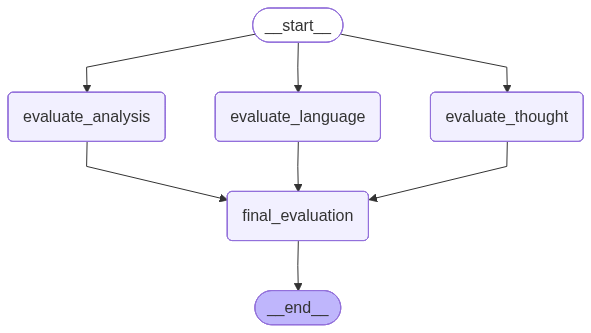

In [103]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')

graph.add_edge('final_evaluation', END)

graph.compile()


In [104]:
workflow = graph.compile()

essay = input("Paste your essay to evaluate and get score based on Language, Depth of analysis and Clarity of thought: ")
initial_state = {'essay': essay}

workflow.invoke(initial_state)

Paste your essay to evaluate and get score based on Language, Depth of analysis and Clarity of thought: # Rise of AI in India  Artificial Intelligence (AI) is one of the fastest-growing technologies in the world today. It is changing the way people work, study, communicate, and live. India is also becoming an important part of this AI revolution. From schools and hospitals to banks and mobile applications, AI is being used in many areas. The rise of AI in India is helping the country grow in technology and innovation.  AI means machines or computers that can perform tasks that usually require human intelligence. These tasks include understanding language, solving problems, recognizing images, and making decisions. Nowadays, many people use AI without even realizing it. Voice assistants like Siri and Google Assistant, online shopping recommendations, and chatbots are all examples of AI.  India has seen rapid growth in AI because of increasing internet usage and digital technology. More 

{'essay': '# Rise of AI in India  Artificial Intelligence (AI) is one of the fastest-growing technologies in the world today. It is changing the way people work, study, communicate, and live. India is also becoming an important part of this AI revolution. From schools and hospitals to banks and mobile applications, AI is being used in many areas. The rise of AI in India is helping the country grow in technology and innovation.  AI means machines or computers that can perform tasks that usually require human intelligence. These tasks include understanding language, solving problems, recognizing images, and making decisions. Nowadays, many people use AI without even realizing it. Voice assistants like Siri and Google Assistant, online shopping recommendations, and chatbots are all examples of AI.  India has seen rapid growth in AI because of increasing internet usage and digital technology. More people now have smartphones and access to online services. This has created a large amount of

In [105]:
# If you need answer in formatted way :

final_answer = workflow.invoke(initial_state)

print(f"Essay :\n  {final_answer['essay']}")
print(f"\n {'-'*50 }")
print(f"Language feedback :\n  {final_answer['language_feedback']}")
print(f"\n {'-'*50 }")
print(f"Depth of Analysis feedback :\n  {final_answer['analysis_feedback']}")
print(f"\n {'-'*50 }")
print(f"Clarity of thought feedback :\n  {final_answer['clarity_feedback']}")
print(f"\n {'-'*50 }")
print(f"Overall feedback :\n  {final_answer['overall_feedback']}")
print(f"\n {'-'*50 }")
print(f"Individual Scores for each feedback :\n  {final_answer['individual_scores']}")
print(f"\n {'-'*50 }")
print(f"Avgy. Score :\n  {final_answer['avg_score']}")
print(f"\n {'-'*50 }")

Essay :
  # Rise of AI in India  Artificial Intelligence (AI) is one of the fastest-growing technologies in the world today. It is changing the way people work, study, communicate, and live. India is also becoming an important part of this AI revolution. From schools and hospitals to banks and mobile applications, AI is being used in many areas. The rise of AI in India is helping the country grow in technology and innovation.  AI means machines or computers that can perform tasks that usually require human intelligence. These tasks include understanding language, solving problems, recognizing images, and making decisions. Nowadays, many people use AI without even realizing it. Voice assistants like Siri and Google Assistant, online shopping recommendations, and chatbots are all examples of AI.  India has seen rapid growth in AI because of increasing internet usage and digital technology. More people now have smartphones and access to online services. This has created a large amount of 